In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [17]:
df= pd.read_csv("dataset/restaurant_bars_2005.csv")

In [18]:
df.head()

,category,company,description,title,review,stars,l_texts
0,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",Big up to my guy Moses who works in the…,Big up to my guy Moses who works in the itsu i...,5,"['big', 'guy', 'moses', 'work', 'itsu', 'gatwi..."
1,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",Great experience at itsu thanks to…,Great experience at itsu thanks to hospitality...,5,"['great_experience', 'itsu', 'thank', 'hospita..."
2,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",As Itsu virgins we enjoyed a lovely…,As Itsu virgins we enjoyed a lovely first time...,5,"['itsu', 'virgin', 'enjoy', 'lovely', 'time', ..."
3,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",ITSU at Brunswick Centre: three cheers for the...,"ITSU at Brunswick Centre, Camden is an extreme...",5,"['itsu', 'brunswick', 'centre', 'camden', 'ext..."
4,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",Itsu Reading Gate is Great,At Itsu Reading Gate and clean restaurant and ...,5,"['itsu', 'read', 'gate', 'clean', 'restaurant'..."


In [19]:
df["word_count"] = df["l_texts"].apply(lambda x: len(str(x).split()))

In [20]:
df.head()

,category,company,description,title,review,stars,l_texts,word_count
0,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",Big up to my guy Moses who works in the…,Big up to my guy Moses who works in the itsu i...,5,"['big', 'guy', 'moses', 'work', 'itsu', 'gatwi...",19
1,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",Great experience at itsu thanks to…,Great experience at itsu thanks to hospitality...,5,"['great_experience', 'itsu', 'thank', 'hospita...",9
2,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",As Itsu virgins we enjoyed a lovely…,As Itsu virgins we enjoyed a lovely first time...,5,"['itsu', 'virgin', 'enjoy', 'lovely', 'time', ...",24
3,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",ITSU at Brunswick Centre: three cheers for the...,"ITSU at Brunswick Centre, Camden is an extreme...",5,"['itsu', 'brunswick', 'centre', 'camden', 'ext...",33
4,Restaurants & Bars,itsu.com,"Delicious, healthy, Asian inspired food, fresh...",Itsu Reading Gate is Great,At Itsu Reading Gate and clean restaurant and ...,5,"['itsu', 'read', 'gate', 'clean', 'restaurant'...",8


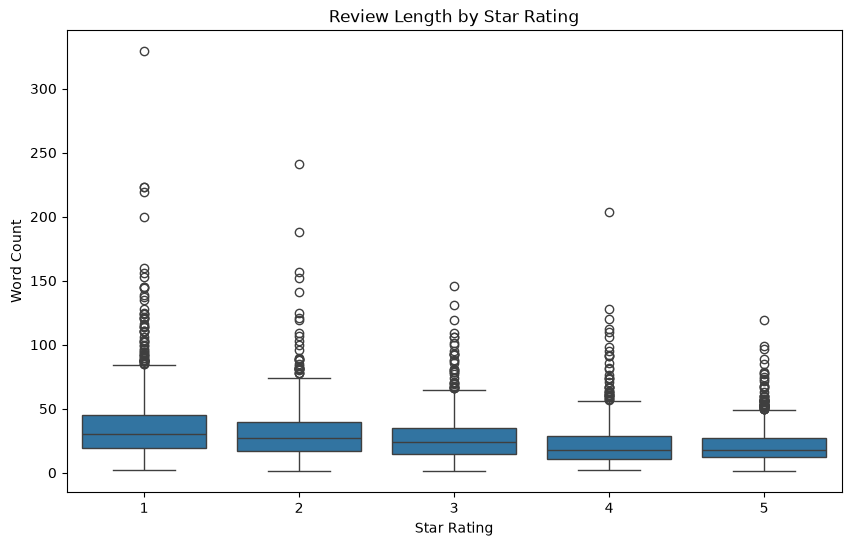

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="stars",
    y="word_count"
)

plt.title("Review Length by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Word Count")

plt.savefig("visualisations/boxplot_review_length_by_star_rating.png")
plt.show()


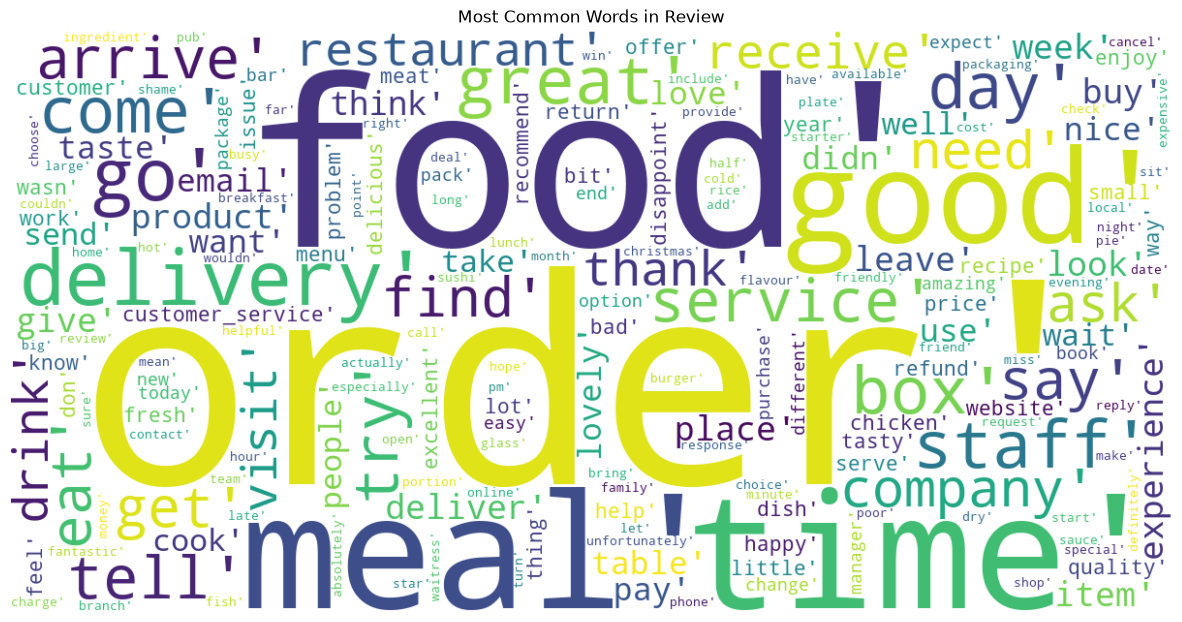

In [22]:
text = " ".join(df["l_texts"].dropna())

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Most Common Words in Review")

plt.savefig("visualisations/wordcloud_reviews.png", dpi=300)
plt.show()


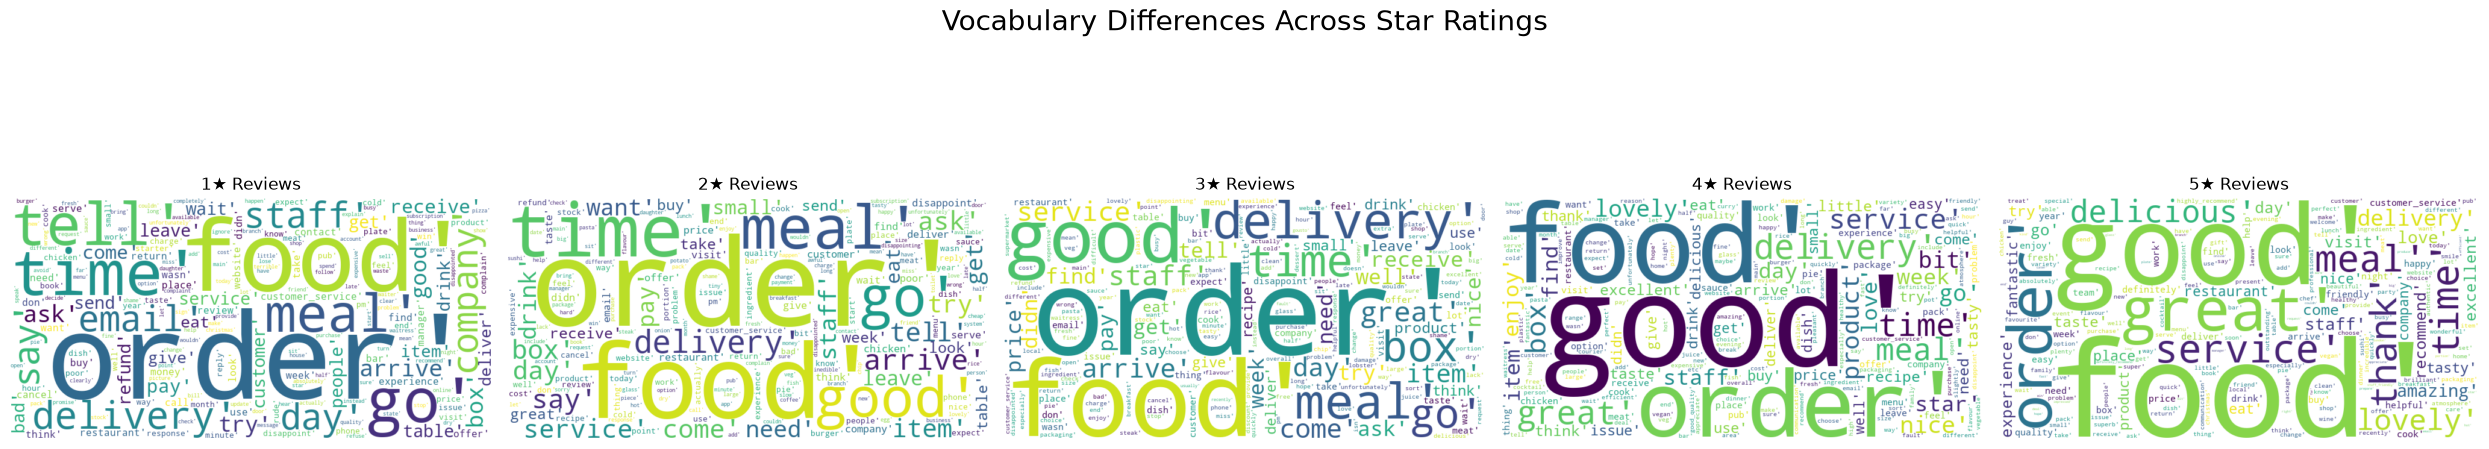

In [23]:
fig, axes = plt.subplots(
    1, 5,
    figsize=(25, 6)
)

for i, stars in enumerate(range(1, 6)):

    # collect text for current rating
    text = " ".join(
        df[df["stars"] == stars]["l_texts"]
        .dropna()
        .astype(str)
    )

    # create word cloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        collocations=False
    ).generate(text)

    # display
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"{stars}★ Reviews")

    plt.suptitle(
    "Vocabulary Differences Across Star Ratings",
    fontsize=20
)

plt.tight_layout()

plt.savefig("visualisations/wordcloud_reviews_by_star_rating.jpg")
plt.show()
